### Imports

In [2]:
import json
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, HPacker
import numpy as np

### Functions

In [57]:
def process_results(path, aggregation_function = np.mean):

    with open(path, 'r') as file:
        data = json.load(file)

    distances = {}
    returns = {}

    for run_number in data:
        
        run_results = data[run_number]
        run_distances = []
        run_returns = []
        
        for noise_level in run_results:

            aggregate_distance = aggregation_function(run_results[noise_level]["distance"])
            aggregate_return = aggregation_function(run_results[noise_level]["cumulative_reward"])

            run_distances.append(aggregate_distance)
            run_returns.append(aggregate_return)

        distances[run_number] = run_distances
        returns[run_number] = run_returns
        
    return distances, returns

In [58]:
def make_numpy_arrays(distances):
    numpy_distances = {noise_type: np.array(distance_matrix) for noise_type, distance_matrix in distances.items()}
    # numpy_returns = {noise_type: np.array(returns_matrix) for noise_type, returns_matrix in returns.items()}

    return numpy_distances

In [59]:
def plot_data(dicts):
    return [item for item in dicts.values()]

In [60]:
def make_graph(matrix, capsize=8):
    plt.figure(figsize=(10, 6))

    values = np.array(list(matrix.values()))
    x = list(matrix.keys())

    # Median
    medians = np.median(values, axis=1)

    # IQR
    q1 = np.quantile(values, 0.25, axis=1)
    q3 = np.quantile(values, 0.75, axis=1)

    lower_errors = medians - q1
    upper_errors = q3 - medians

    yerr = np.vstack([lower_errors, upper_errors])

    # Plot with caps
    plt.errorbar(x, medians, yerr=yerr, fmt='o', capsize=capsize, ecolor='black', markerfacecolor='blue')

In [61]:
COLORS = {
    "Base": "tab:blue",
    "Observation": "tab:orange",
    "Action": "tab:green",
    "Transition": "tab:red",
}

def plot_data_mean(data, ax, label):
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    n = data.shape[0]
    ci = 1.96 * std / np.sqrt(n)
    
    x = np.linspace(0, 1, 10)
    
    line, = ax.plot(x, mean, label=label, color=COLORS[label])
    ax.fill_between(x, mean - ci, mean + ci,
                    alpha=0.2,
                    color=line.get_color())
    
    ax.set_xlabel("Standard deviation of the noise")
    ax.set_ylabel("Mean distance travelled")

def plot_data_median(data, ax, label, lower_q=0.25, upper_q=0.75, y_label="Mean distance traveled"):
    median = np.median(data, axis=0)
    lower = np.quantile(data, lower_q, axis=0)
    upper = np.quantile(data, upper_q, axis=0)

    x = np.linspace(0, 1, data.shape[1])

    line, = ax.plot(x, median, label=label, color=COLORS[label])
    ax.fill_between(
        x,
        lower,
        upper,
        alpha=0.2,
        color=line.get_color()
    )

    ax.set_xlabel("Noise factor $\sigma$")
    ax.set_ylabel(y_label)

### Hopper Task

In [62]:
base_hopper_distances, base_hopper_returns = process_results("../results/all_noise/allnoise_base_agent_Hopper-v5.json")
baseppo_hopper_distances, baseppo_hopper_returns = process_results("../results/all_noise/allnoise_baseppo_agent_Hopper-v5.json")
state_hopper_distances, state_hopper_returns = process_results("../results/all_noise/allnoise_state_agent_Hopper-v5.json")
stateppo_hopper_distances, stateppo_hopper_returns = process_results("../results/all_noise/allnoise_stateppo_agent_Hopper-v5.json")
action_hopper_distances, action_hopper_returns = process_results("../results/all_noise/allnoise_action_agent_Hopper-v5.json")
transition_hopper_distances, transition_hopper_returns = process_results("../results/all_noise/allnoise_transition_agent_Hopper-v5.json")

In [64]:
base_hopper_distances = np.array(plot_data(base_hopper_distances))
baseppo_hopper_distances = np.array(plot_data(baseppo_hopper_distances))
state_hopper_distances = np.array(plot_data(state_hopper_distances))
stateppo_hopper_distances = np.array(plot_data(stateppo_hopper_distances))
action_hopper_distances = np.array(plot_data(action_hopper_distances))
transition_hopper_distances = np.array(plot_data(transition_hopper_distances))

base_hopper_returns = np.array(plot_data(base_hopper_returns))
baseppo_hopper_returns = np.array(plot_data(baseppo_hopper_returns))
state_hopper_returns = np.array(plot_data(state_hopper_returns))
stateppo_hopper_returns = np.array(plot_data(stateppo_hopper_returns))
action_hopper_returns = np.array(plot_data(action_hopper_returns))
transition_hopper_returns = np.array(plot_data(transition_hopper_returns))

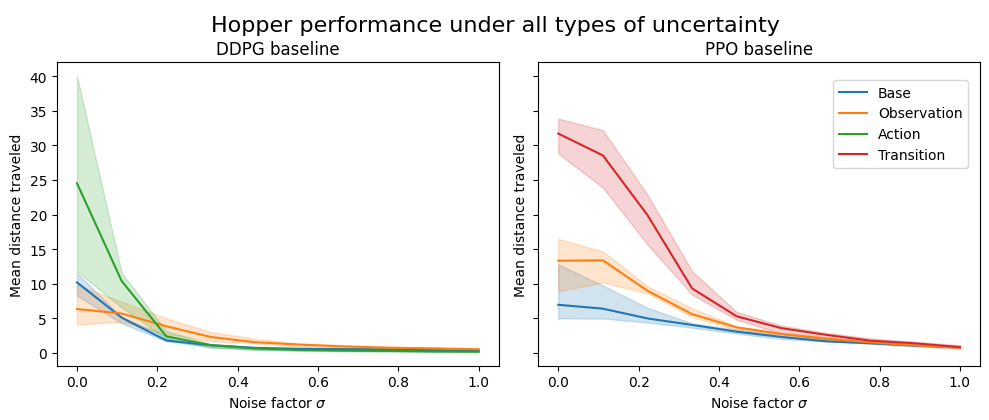

In [65]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

title_size = 16  # similar to default suptitle size

t1 = TextArea("Hopper performance under all types of uncertainty",
              textprops=dict(fontsize=title_size))

box = HPacker(children=[t1], align="center", pad=0, sep=0)

anchored_box = AnchoredOffsetbox(
    loc="upper center",
    child=box,
    frameon=False,
    bbox_to_anchor=(0.5, 1.04),   # move title higher
    bbox_transform=fig.transFigure,
    borderpad=0
)

fig.add_artist(anchored_box)

# First subplot
plot_data_median(base_hopper_distances, axes[0], "Base")
plot_data_median(state_hopper_distances, axes[0], "Observation")
plot_data_median(action_hopper_distances, axes[0], "Action")
axes[0].set_title("DDPG baseline")

# Second subplot
plot_data_median(baseppo_hopper_distances, axes[1], "Base")
plot_data_median(stateppo_hopper_distances, axes[1], "Observation")
# plot_data(actionppo_distances["state"], axes[1], "Action")
plot_data_median(transition_hopper_distances, axes[1], "Transition")
axes[1].set_title("PPO baseline")

# Add legends only once (optional)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# remove duplicates while preserving order
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper right",
    bbox_to_anchor=(0.98, 0.88),  # tweak as needed
    frameon=True
)

plt.tight_layout()
plt.show()

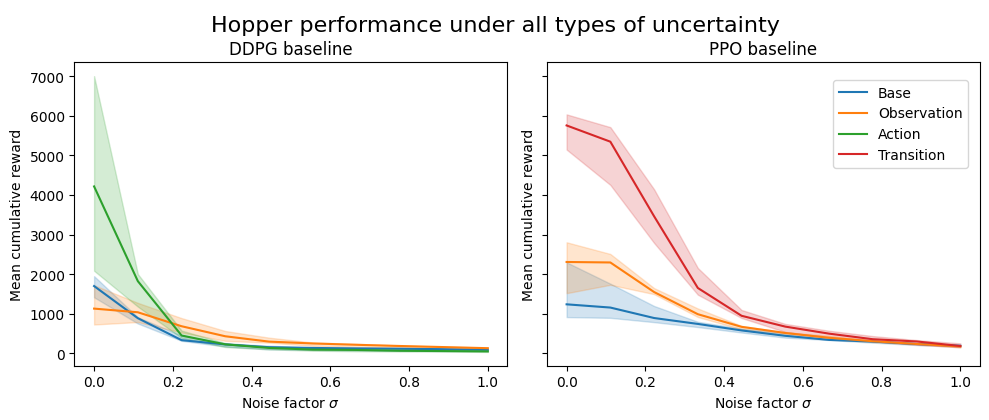

In [66]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

title_size = 16  # similar to default suptitle size

t1 = TextArea("Hopper performance under all types of uncertainty",
              textprops=dict(fontsize=title_size))

box = HPacker(children=[t1], align="center", pad=0, sep=0)

anchored_box = AnchoredOffsetbox(
    loc="upper center",
    child=box,
    frameon=False,
    bbox_to_anchor=(0.5, 1.04),   # move title higher
    bbox_transform=fig.transFigure,
    borderpad=0
)

fig.add_artist(anchored_box)

# First subplot
plot_data_median(base_hopper_returns, axes[0], "Base", y_label="Mean cumulative reward")
plot_data_median(state_hopper_returns, axes[0], "Observation", y_label="Mean cumulative reward")
plot_data_median(action_hopper_returns, axes[0], "Action", y_label="Mean cumulative reward")
axes[0].set_title("DDPG baseline")

# Second subplot
plot_data_median(baseppo_hopper_returns, axes[1], "Base", y_label="Mean cumulative reward")
plot_data_median(stateppo_hopper_returns, axes[1], "Observation", y_label="Mean cumulative reward")
plot_data_median(transition_hopper_returns, axes[1], "Transition", y_label="Mean cumulative reward")
axes[1].set_title("PPO baseline")

# Add legends only once (optional)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# remove duplicates while preserving order
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper right",
    bbox_to_anchor=(0.98, 0.88),  # tweak as needed
    frameon=True
)

plt.tight_layout()
plt.show()

### Walker Task

In [67]:
base_walker_distances, base_walker_returns = process_results("../results/all_noise/allnoise_base_agent_Walker2d-v5.json")
baseppo_walker_distances, baseppo_walker_returns = process_results("../results/all_noise/allnoise_baseppo_agent_Walker2d-v5.json")
state_walker_distances, state_walker_returns = process_results("../results/all_noise/allnoise_state_agent_Walker2d-v5.json")
stateppo_walker_distances, stateppo_walker_returns = process_results("../results/all_noise/allnoise_stateppo_agent_Walker2d-v5.json")
action_walker_distances, action_walker_returns = process_results("../results/all_noise/allnoise_action_agent_Walker2d-v5.json")
transition_walker_distances, transition_walker_returns = process_results("../results/all_noise/allnoise_transition_agent_Walker2d-v5.json")

In [68]:
base_walker_distances = np.array(plot_data(base_walker_distances))
baseppo_walker_distances = np.array(plot_data(baseppo_walker_distances))
state_walker_distances = np.array(plot_data(state_walker_distances))
stateppo_walker_distances = np.array(plot_data(stateppo_walker_distances))
action_walker_distances = np.array(plot_data(action_walker_distances))
transition_walker_distances = np.array(plot_data(transition_walker_distances))

base_walker_returns = np.array(plot_data(base_walker_returns))
baseppo_walker_returns = np.array(plot_data(baseppo_walker_returns))
state_walker_returns = np.array(plot_data(state_walker_returns))
stateppo_walker_returns = np.array(plot_data(stateppo_walker_returns))
action_walker_returns = np.array(plot_data(action_walker_returns))
transition_walker_returns = np.array(plot_data(transition_walker_returns))

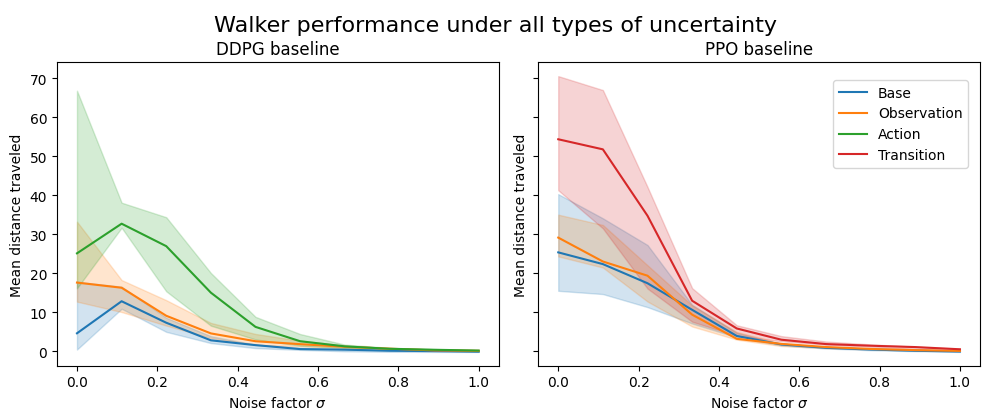

In [69]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

title_size = 16  # similar to default suptitle size

t1 = TextArea("Walker performance under all types of uncertainty",
              textprops=dict(fontsize=title_size))

box = HPacker(children=[t1], align="center", pad=0, sep=0)

anchored_box = AnchoredOffsetbox(
    loc="upper center",
    child=box,
    frameon=False,
    bbox_to_anchor=(0.5, 1.04),   # move title higher
    bbox_transform=fig.transFigure,
    borderpad=0
)

fig.add_artist(anchored_box)

# First subplot
plot_data_median(base_walker_distances, axes[0], "Base")
plot_data_median(state_walker_distances, axes[0], "Observation")
plot_data_median(action_walker_distances, axes[0], "Action")
axes[0].set_title("DDPG baseline")

# Second subplot
plot_data_median(baseppo_walker_distances, axes[1], "Base")
plot_data_median(stateppo_walker_distances, axes[1], "Observation")
# plot_data(actionppo_distances["state"], axes[1], "Action")
plot_data_median(transition_walker_distances, axes[1], "Transition")
axes[1].set_title("PPO baseline")

# Add legends only once (optional)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# remove duplicates while preserving order
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper right",
    bbox_to_anchor=(0.98, 0.88),  # tweak as needed
    frameon=True
)

plt.tight_layout()
plt.show()

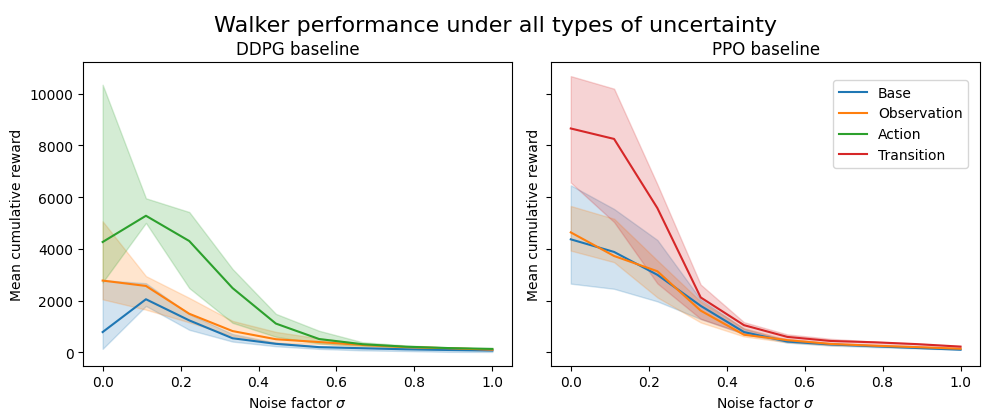

In [70]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

title_size = 16  # similar to default suptitle size

t1 = TextArea("Walker performance under all types of uncertainty",
              textprops=dict(fontsize=title_size))

box = HPacker(children=[t1], align="center", pad=0, sep=0)

anchored_box = AnchoredOffsetbox(
    loc="upper center",
    child=box,
    frameon=False,
    bbox_to_anchor=(0.5, 1.04),   # move title higher
    bbox_transform=fig.transFigure,
    borderpad=0
)

fig.add_artist(anchored_box)

# First subplot
plot_data_median(base_walker_returns, axes[0], "Base", y_label="Mean cumulative reward")
plot_data_median(state_walker_returns, axes[0], "Observation", y_label="Mean cumulative reward")
plot_data_median(action_walker_returns, axes[0], "Action", y_label="Mean cumulative reward")
axes[0].set_title("DDPG baseline")

# Second subplot
plot_data_median(baseppo_walker_returns, axes[1], "Base", y_label="Mean cumulative reward")
plot_data_median(stateppo_walker_returns, axes[1], "Observation", y_label="Mean cumulative reward")
plot_data_median(transition_walker_returns, axes[1], "Transition", y_label="Mean cumulative reward")
axes[1].set_title("PPO baseline")

# Add legends only once (optional)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# remove duplicates while preserving order
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper right",
    bbox_to_anchor=(0.98, 0.88),  # tweak as needed
    frameon=True
)

plt.tight_layout()
plt.show()